# K-Means sur MNIST

Algorithme de Lloyd from scratch ([src/kmeans.py](../src/kmeans.py)). K-Means vu comme quantification vectorielle :

- `encode(X)` : indice du centroïde le plus proche par image -> code latent discret.
- `decode(latent)` : code -> centroïde correspondant -> reconstruction.
- `get_codebook()` : les K centroïdes -> dictionnaire partagé pour la décompression.

Trois angles : projection/visualisation, compression/décompression, clusters euclidiens vs classes réelles.

In [2]:
import sys
from pathlib import Path

# src/ importable et place la racine du projet comme dossier courant
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
import os
os.chdir(ROOT)

import numpy as np
import matplotlib.pyplot as plt

from src.kmeans import KMeans
from src.metrics import compression_report
from src.dataset import load_mnist_dataset
from src.helper import extract_full_dataset

rng = np.random.default_rng(0)
%matplotlib inline


## 1. Chargement et préparation

- Tenseur 4D `(N, 1, 28, 28)` -> `.flatten(start_dim=1)` -> vecteurs 784D.
- Pixels `ToTensor()` déjà dans `[0, 1]` : distance euclidienne homogène entre dimensions, pas de standardisation.

In [3]:
train_loader = load_mnist_dataset(train=True, download=True, shuffle=False, batch_size=512)
test_loader = load_mnist_dataset(train=False, download=True, shuffle=False, batch_size=512)

train_imgs, train_labels = extract_full_dataset(train_loader)
test_imgs, test_labels = extract_full_dataset(test_loader)

# Aplatissement (N, 1, 28, 28) -> (N, 784), conversion NumPy float32
X_train = train_imgs.flatten(start_dim=1).numpy().astype(np.float32)
X_test = test_imgs.flatten(start_dim=1).numpy().astype(np.float32)
y_train = train_labels.numpy()
y_test = test_labels.numpy()

print("X_train:", X_train.shape, X_train.dtype, "| pixels dans [", X_train.min(), ",", X_train.max(), "]")
print("X_test :", X_test.shape)


X_train: (60000, 784) float32 | pixels dans [ 0.0 , 1.0 ]
X_test : (10000, 784)


## 2. Entraînement, k = 10

- k = 10 : une classe par chiffre, point de départ naturel.
- `n_init` relances k-means++, meilleure inertie retenue : Lloyd ne converge que vers un minimum local, l'amorçage k-means++ et les relances réduisent le risque de mauvaise solution.
- Inertie = somme des distances au carré point-centroïde.

In [4]:
kmeans = KMeans(n_clusters=10, n_init=4, max_iter=100, random_state=0)
kmeans.fit(X_train)

print(f"Inertie      : {kmeans.inertia_:,.0f}")
print(f"Itérations   : {kmeans.n_iter_}")
print(f"Centroïdes   : {kmeans.centroids_.shape}")


Inertie      : 2,352,966
Itérations   : 100
Centroïdes   : (10, 784)


### Validation contre scikit-learn

- Inertie comparée à `sklearn.cluster.KMeans`, mêmes conditions. Écart quasi nul attendu.

In [5]:
from sklearn.cluster import KMeans as SkKMeans

sk = SkKMeans(n_clusters=10, n_init=4, max_iter=100, random_state=0).fit(X_train)
print(f"Inertie (notre implémentation) : {kmeans.inertia_:,.0f}")
print(f"Inertie (scikit-learn)         : {sk.inertia_:,.0f}")
print(f"Écart relatif                  : {abs(kmeans.inertia_ - sk.inertia_) / sk.inertia_:.4%}")


Inertie (notre implémentation) : 2,352,966
Inertie (scikit-learn)         : 2,352,826
Écart relatif                  : 0.0059%


## 3. Visualisation du dictionnaire (codebook)

- Centroïdes dans l'espace des pixels -> réaffichés en images 28x28.
- Prototypes appris : chiffres moyens, flous là où plusieurs chiffres partagent une forme.

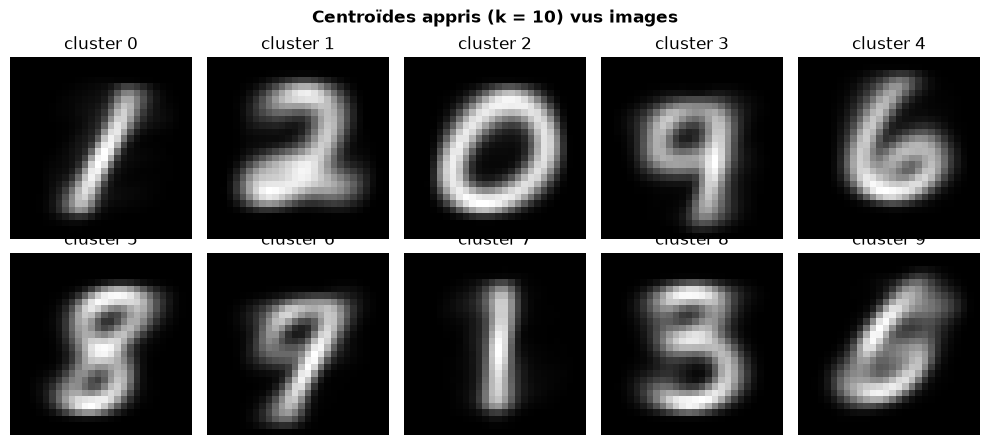

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4.5))
for k, ax in enumerate(axes.ravel()):
    ax.imshow(kmeans.centroids_[k].reshape(28, 28), cmap="gray")
    ax.set_title(f"cluster {k}")
    ax.axis("off")
fig.suptitle("Centroïdes appris (k = 10) vus images", fontweight="bold")
plt.tight_layout()
plt.show()


## 4. Compression et décompression

- Encodage test -> un entier de cluster par image ; décodage -> centroïde.
- `compression_report` : poids dictionnaire + codes latents, MSE de reconstruction.
- Compromis : 1 entier/image + K centroïdes partagés au lieu de 784 flottants. Reconstruction grossière car toutes les images d'un cluster partagent le même centroïde décodé.

In [7]:
latent = kmeans.encode(X_test)
X_rec = kmeans.decode(latent)

report = compression_report(kmeans.get_codebook(), latent, X_test, X_rec)
for key, value in report.items():
    print(f"{key:>24} : {value}")


           latent_nature : discrete
          codebook_bytes : 31360
            latent_bytes : 10000
  total_compressed_bytes : 41360
          original_bytes : 31360000
       compression_ratio : 758.2205029013539
      reconstruction_mse : 0.04991796612739563


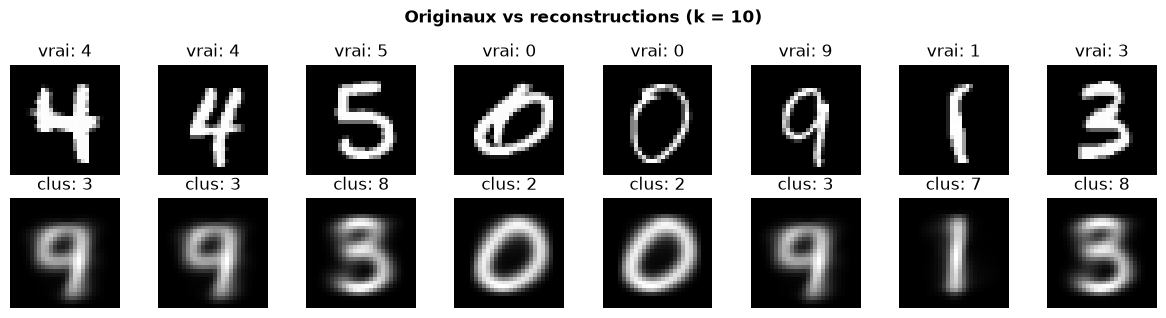

In [8]:
# Comparaison visuelle : image originale (haut) vs sa reconstruction par centroïde (bas)
sample_idx = rng.choice(len(X_test), size=8, replace=False)
fig, axes = plt.subplots(2, 8, figsize=(12, 3.2))
for col, i in enumerate(sample_idx):
    axes[0, col].imshow(X_test[i].reshape(28, 28), cmap="gray")
    axes[0, col].set_title(f"vrai: {y_test[i]}")
    axes[0, col].axis("off")
    axes[1, col].imshow(X_rec[i].reshape(28, 28), cmap="gray")
    axes[1, col].set_title(f"clus: {latent.array[i]}")
    axes[1, col].axis("off")
axes[0, 0].set_ylabel("original")
axes[1, 0].set_ylabel("reconstruit")
fig.suptitle("Originaux vs reconstructions (k = 10)", fontweight="bold")
plt.tight_layout()
plt.show()


## 5. Choix de k : méthode du coude

- Inertie tracée sur un balayage de k. Décroît toujours avec k (k = N -> inertie nulle) : pas de minimum, on cherche le coude où le gain marginal s'effondre.
- Balayage sur sous-échantillon pour rester rapide et ré-exécutable.

In [9]:
subset = rng.choice(len(X_train), size=10000, replace=False)
X_sub = X_train[subset]

k_values = [5, 8, 10, 12, 16, 20, 30, 40]
inertias = []
for k in k_values:
    model = KMeans(n_clusters=k, n_init=3, max_iter=100, random_state=0).fit(X_sub)
    inertias.append(model.inertia_)
    print(f"k = {k:>2}  ->  inertie = {model.inertia_:,.0f}")


k =  5  ->  inertie = 434,160
k =  8  ->  inertie = 404,911
k = 10  ->  inertie = 392,431
k = 12  ->  inertie = 380,039
k = 16  ->  inertie = 363,744
k = 20  ->  inertie = 350,412
k = 30  ->  inertie = 328,878
k = 40  ->  inertie = 314,925


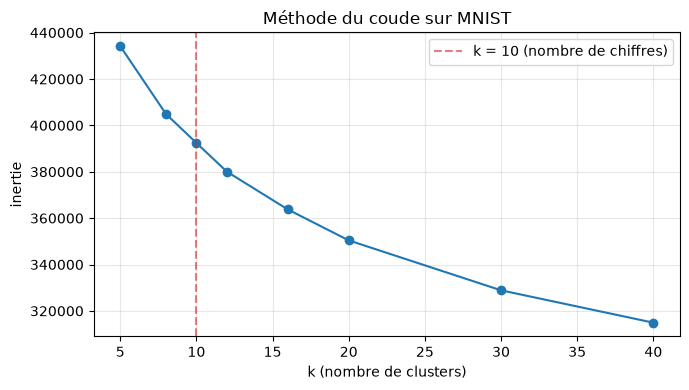

In [10]:
plt.figure(figsize=(7, 4))
plt.plot(k_values, inertias, "o-")
plt.axvline(10, color="tab:red", linestyle="--", alpha=0.6, label="k = 10 (nombre de chiffres)")
plt.xlabel("k (nombre de clusters)")
plt.ylabel("inertie")
plt.title("Méthode du coude sur MNIST")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 6. Clusters vs chiffres

- K-Means ignore les étiquettes, regroupe par proximité euclidienne dans l'espace des pixels.
- Lien mesuré a posteriori : chaque cluster reçoit son chiffre majoritaire, précision du classement induit calculée.

In [11]:
def majority_vote_accuracy(labels_pred, labels_true, n_clusters):
    mapping = {}
    for c in range(n_clusters):
        members = labels_true[labels_pred == c]
        mapping[c] = np.bincount(members, minlength=10).argmax() if members.size else -1
    mapped = np.array([mapping[c] for c in labels_pred])
    return (mapped == labels_true).mean(), mapping


acc, mapping = majority_vote_accuracy(kmeans.labels_, y_train, 10)
print(f"Précision par vote majoritaire (k = 10) : {acc:.2%}\n")
for c in range(10):
    members = y_train[kmeans.labels_ == c]
    counts = np.bincount(members, minlength=10)
    purity = counts.max() / counts.sum()
    print(f"cluster {c}: chiffre dominant = {mapping[c]}  |  pureté = {purity:.1%}  |  taille = {counts.sum()}")


Précision par vote majoritaire (k = 10) : 58.26%

cluster 0: chiffre dominant = 1  |  pureté = 66.6%  |  taille = 4566
cluster 1: chiffre dominant = 2  |  pureté = 91.7%  |  taille = 4533
cluster 2: chiffre dominant = 0  |  pureté = 94.1%  |  taille = 4573
cluster 3: chiffre dominant = 4  |  pureté = 35.7%  |  taille = 8924
cluster 4: chiffre dominant = 6  |  pureté = 86.8%  |  taille = 4302
cluster 5: chiffre dominant = 8  |  pureté = 60.0%  |  taille = 5845
cluster 6: chiffre dominant = 7  |  pureté = 44.0%  |  taille = 8569
cluster 7: chiffre dominant = 1  |  pureté = 62.6%  |  taille = 5833
cluster 8: chiffre dominant = 3  |  pureté = 52.5%  |  taille = 7352
cluster 9: chiffre dominant = 6  |  pureté = 31.8%  |  taille = 5503


- Confusions classiques (4/9, 3/5/8, 7/9) : chiffres proches en pixels tombent dans le même cluster ; un chiffre à deux styles se scinde en deux clusters.
- k au-delà de 10 fait monter la pureté : chaque cluster capture un style d'écriture plus fin.

In [12]:
for k in [10, 20, 40, 60]:
    model = KMeans(n_clusters=k, n_init=2, max_iter=100, random_state=0).fit(X_sub)
    y_sub = y_train[subset]
    acc_k, _ = majority_vote_accuracy(model.labels_, y_sub, k)
    print(f"k = {k:>2}  ->  précision par vote majoritaire = {acc_k:.2%}")


k = 10  ->  précision par vote majoritaire = 53.57%
k = 20  ->  précision par vote majoritaire = 72.07%
k = 40  ->  précision par vote majoritaire = 79.07%
k = 60  ->  précision par vote majoritaire = 81.77%


## 7. Conclusions

- Projection : centroïdes = prototypes lisibles, carte grossière mais interprétable de la structure.
- Compression : gain énorme (1 entier/image + K centroïdes) contre reconstruction grossière (centroïde partagé). Compromis débit/qualité extrême.
- Clusters vs classes : à k = 10, correspondance imparfaite (~55-60 %). K-Means ne sépare bien que si des clusters euclidiens existent dans l'espace de départ, ce qui n'est que partiellement vrai sur pixels bruts. k plus grand améliore la pureté au prix d'un dictionnaire plus lourd.